# 🛢️ Oil Spill Detection — MLP de classification
**Dataset** : Sentinel-1 SAR Oil Spill Detection Dataset (Kaggle)  
**Objectif** : Entraîner un MLP sur les images et mesurer sa performance



## 1. Libairies

In [ ]:

import os
import pandas as pd
import plotly.express as px
import json
import random
import cv2
import numpy as np


from PIL import Image
from pathlib import Path

!pip install torchmetrics



Imports OK


In [1]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 9.1 MB/s eta 0:00:00


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import hashlib
import kagglehub
import random
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics

from collections import Counter
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from torchmetrics import Accuracy
from torch.utils.data import DataLoader, Subset, TensorDataset, random_split
from torchvision import transforms


print('Imports OK')

Imports OK


## 2. Importation des données


### a) Téléchargement du dataset




In [5]:
# Téléchargement depuis kaggle

path = kagglehub.dataset_download("harikrishnacs/sentinel-1-sar-oil-spill-detection-dataset")
root = Path(path + "/data/S1SAR_UnBalanced_400by400_Class_")
print(f"Dataset : {root}")

Using Colab cache for faster access to the 'sentinel-1-sar-oil-spill-detection-dataset' dataset.
Dataset : /kaggle/input/sentinel-1-sar-oil-spill-detection-dataset/data/S1SAR_UnBalanced_400by400_Class_


In [8]:
# Liste de toutes les images

items = []
for label in [0, 1]:
    folder = Path(str(root) + str(label) + "/" + str(label))
    files  = sorted(folder.glob("*.jpg"))
    items += [(f, label) for f in files]

random.shuffle(items)

n0 = sum(1 for _, l in items if l == 0)
n1 = sum(1 for _, l in items if l == 1)
print(f"Classe 0 (sans huile) : {n0} images : {n0/len(items)*100:.1f} du dataset")
print(f"Classe 1 (avec huile) : {n1} images : {n1/len(items)*100:.1f} du dataset")
print(f"Total                 : {len(items)} images")

Classe 0 (sans huile) : 3725 images : 66.2 du dataset
Classe 1 (avec huile) : 1905 images : 33.8 du dataset
Total                 : 5630 images


In [9]:
# Format des images

img_path, label = items[0]

with Image.open(img_path) as img:
    width, height = img.size
    mode = img.mode

print(f"Résolution : {width}x{height}")
print(f"Format couleur : {mode}")

Résolution : 400x400
Format couleur : RGB


**ANALYSE :**

Les images sont donc au format 400x400, et possèdent 3 canaux (RGB).

### b) Suppression des duplicats

In [10]:
# Présence de dupplicats

def check_duplicates(items):
    hashes = {}
    duplicates = []

    for path, label in items:
        # Lire le contenu binaire du fichier
        with open(path, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()

        if file_hash in hashes:
            duplicates.append((path, hashes[file_hash]))
        else:
            hashes[file_hash] = path

    if duplicates:
        print(f"⚠️ {len(duplicates)} doublons trouvés !")
        # Optionnel : afficher les deux premiers pour vérification
        for dup, orig in duplicates[:3]:
            print(f"  - {dup.name} est identique à {orig.name}")
    else:
        print("✅ Aucun doublon détecté.")

    return duplicates

dups = check_duplicates(items)


⚠️ 92 doublons trouvés !
  - 6_400_200_img_ZRMXxf2eJZjkJzYA_GGu_cls_1.jpg est identique à 6_400_200_img_UERfk6hkc2hgJ8EQ_GGu_cls_1.jpg
  - 0_0_0_img_tddamD15qnZkdXsY_GBR_cls_0.jpg est identique à 0_0_0_img_YYf5AYrift0oe2O1_GBR_cls_0.jpg
  - 2142_3600_7400_img_EghQqXp4K4k6GyDJ_SIN_cls_1.jpg est identique à 2142_3600_7400_img_LQjVMscVXLUkhIwX_SIN_cls_1.jpg


In [11]:
# Création d'un set de hashes pour supprimer les duplicats

seen_hashes = set()
unique_items = []

for path, label in items:
    with open(path, "rb") as f:
        h = hashlib.md5(f.read()).hexdigest()
    if h not in seen_hashes:
        unique_items.append((path, label))
        seen_hashes.add(h)

items = unique_items
print(f"Nouveau total après nettoyage : {len(items)}")

Nouveau total après nettoyage : 5538


### c) Distribution des images par classe

In [13]:
# Distribution des images par classe après nettoyage

u_n0 = sum(1 for _, l in unique_items if l == 0)
u_n1 = sum(1 for _, l in unique_items if l == 1)

print(f"Classe 0 (sans pétrole) : {u_n0} images : {u_n0/len(unique_items)*100:.1f} du dataset")
print(f"Classe 1 (avec pétrole) : {u_n1} images : {u_n1/len(unique_items)*100:.1f} du dataset")
print(f"Total                 : {len(unique_items)} images")

Classe 0 (sans pétrole) : 3694 images : 66.7 du dataset
Classe 1 (avec pétrole) : 1844 images : 33.3 du dataset
Total                 : 5538 images


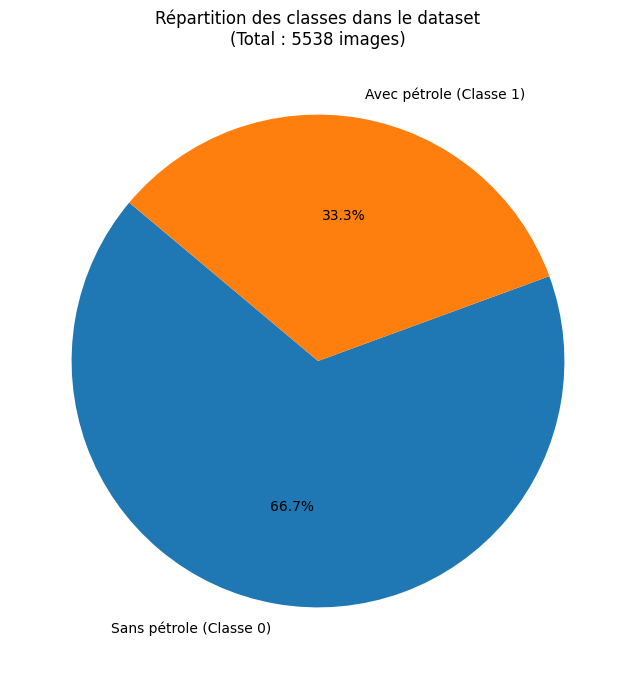

In [14]:
# Graphique

labels = ['Sans pétrole (Classe 0)', 'Avec pétrole (Classe 1)']
sizes = [u_n0, u_n1]

plt.figure(figsize=(8, 8))
plt.pie(sizes,
        labels=labels,
        autopct='%1.1f%%', # Affiche le pourcentage
        startangle=140)

plt.title(f"Répartition des classes dans le dataset\n(Total : {len(unique_items)} images)")
plt.show()

**ANALYSE :**

On observe un important déséquilibre de classe, avec seulement 33,3% des images représentants la classe 1 (avec trace de pétrole).

Le modèle aura ainsi tendance à prédire plus fréquemment la classe 0, pour la seule raison qu'elle est plus présente dans le jeu de données, au lieu de se concentrer sur les caractéristiques propres des images de la classe 1.

Il s'agira donc de corriger ce déséquilibre de classes à l'aide d'une des méthodes suivantes :
- **Une pondération de la fonction de perte**, qui donnera ainsi artificiellement plus de poids à la classe minoritaire et moins à la classe majoritaire, corrigeant les biais induits par le déséquilibre.
- **Le Sampler** : au lieu de pondérer la fonction de poids, le sampler va affecter le DataLoader, en le forçant à piocher plus souvent dans la classe minoritaire pour compenser.


Enfin, en présence d'un déséquilibre de classes, **l'utilisation de métriques d'évaluation robustes** est importante. En effet, utiliser uniquement l'accuracy ne sera pas suffisant car un modèle fainéant, prédisant les classes selon leur pourcentage de présence dans le dataset, peut avoir une bonne accuracy. Il faudra ainsi aussi utiliser le recall et la précision pour évaluer plus finement la capacité du modèle à reconnaître des images d'une classe majoritaire ou minoritaire.



## 2. Préparation des données

###a) Dimensionnement et normalisation des données

La plupart des modèles demandent des données préalablement converties en *tensors* (matrices à plus de 2 dimensions), et *normalisées* pour fluidifier et alléger leur traitement.

Ici, comme les images sont en noir et blanc, on crée une fonction pour les redimensionner de (400 x 400 x 3) au format suivant(1 x 28 x 28).

On les normalize ensuite avec le Z-score.

In [16]:
# Fonction de redimensionnement et de normalisation

# On resize les images de 400x400 à 28x28 (moins lourd et plus adapté à un MLP)
IMG_SIZE = (28, 28)

def load_image(path):
    """Charge une image JPG et la normalise."""
    img_size = Image.open(path).size
    img = Image.open(path).convert("L").resize(IMG_SIZE)      # resize ici, L car image en noir et blanc
    img = np.array(img).astype(np.float32) / 255.0            # normalize depuis l'image redimensionnée

    # Z-score
    mu     = img.mean()
    std    = img.std() + 1e-6
    img    = (img - mu) / std
    img = np.expand_dims(img, axis=0)

    return img


# Test sur une image pour vérifier
img_test, label_test = items[0]
img_array = load_image(img_test)
print("Test sur une image")
print(f"Shape image chargée : {img_array.shape}")
print(f"Label               : {label_test}")
print(f"Valeurs min/max     : {img_array.min():.2f} / {img_array.max():.2f}")

Test sur une image
Shape image chargée : (1, 28, 28)
Label               : 1
Valeurs min/max     : -7.11 / 1.78


### b) Création des jeux d'entraînement, de validation et de test

On divise le jeu de données en trois ensembles distinct :
- **Le jeu d'entraînement**

Le jeu d'entraînement constitue la base de connaissances du modèle. C'est sur cet ensemble que l'algorithme de rétropropagation ajuste les poids du réseau de neurones.

- **Le jeu de validation**

Le jeu de validation oriente notre choix des hyperparamètres (taux d'apprentissage, nombre d'époques) pendant la phase d'apprentissage. Contrairement au jeu d'entraînement, le modèle n'ajuste pas ses poids sur ces données. Elles sont utilisées pour évaluer ses performances à la fin de chaque époque.

- **Le jeu de test**

Le jeu de test représente l'évaluation finale et impartiale du système. Il simule le déploiement du modèle sur des données réelles et totalement inconnues.



In [18]:
# Hyperparamètres
BATCH_SIZE = 32
SEED = 42
TEST_SPLIT = 0.15
VAL_SPLIT = 0.15

In [19]:
# Découpage train / val / test

print("Préparation des données en mémoire...")
X_list = []
y_list = []

# Collecte et normalisation
for path, label in items:
    X_list.append(load_image(path))
    y_list.append(label)

# Conversion en torch.tensor
X = torch.tensor(np.array(X_list))
y = torch.tensor(y_list).long()

dataset = TensorDataset(X, y)

# Division en train, val, test
n_total = len(dataset)
n_test  = int(n_total * TEST_SPLIT)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val - n_test

train_ds, val_ds, test_ds = random_split(
    dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Train : {n_train} | Val : {n_val} | Test : {n_test}")
print(f"Vérification : {X.shape}")

Préparation des données en mémoire...
Train : 3878 | Val : 830 | Test : 830
Vérification : torch.Size([5538, 1, 28, 28])


On vérifie ensuite la r**épartition des classes au sein du jeu d’entraînement**. C’est en effet le déséquilibre au sein de ce jeu qui va nous permettre de calculer les poids pour pondérer la fonction de perte, et limiter les biais d’apprentissage liés au déséquilibre. Ces poids sont calculés comme inversement proportionnels à la fréquence de la classe.

In [20]:
# Evaluation du déséquilibre de classes au sein du jeu d'entraînement

# Récupérer les labels du subset de train uniquement
train_indices = train_ds.indices
train_labels = y[train_indices].tolist()

# Décompte des occurrences
counts = Counter(train_labels)
print(f"Répartition dans le TRAIN : {counts}")

total_train = len(train_labels)
num_classes = len(counts)

Répartition dans le TRAIN : Counter({0: 2556, 1: 1322})


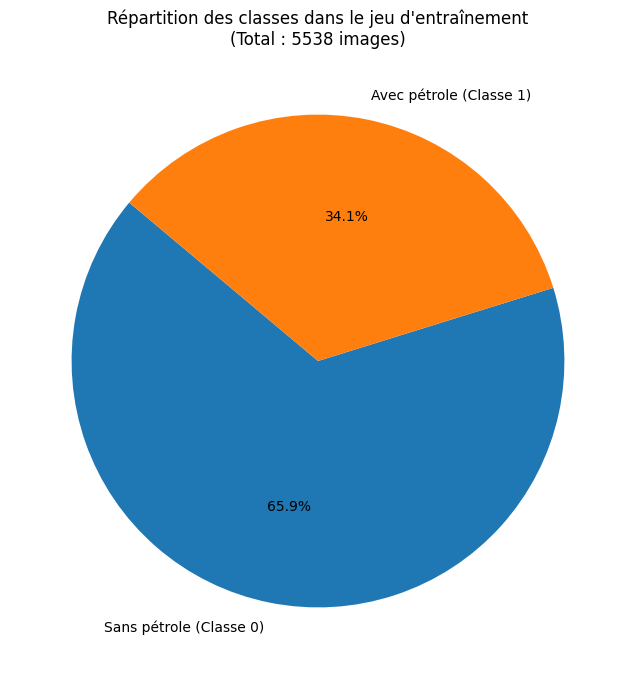

In [21]:
# Graphique

labels = ['Sans pétrole (Classe 0)', 'Avec pétrole (Classe 1)']
sizes = [counts[0]/total_train, counts[1]/total_train]

plt.figure(figsize=(8, 8))
plt.pie(sizes,
        labels=labels,
        autopct='%1.1f%%', # Affiche le pourcentage
        startangle=140)

plt.title(f"Répartition des classes dans le jeu d'entraînement\n(Total : {len(unique_items)} images)")
plt.show()

In [22]:
# Calcul des poids inversement proportionnels à la fréquence
# Formule : poids = total_samples / (n_classes * n_samples_of_class)

# On crée un tenseur de poids (ex: [poids_classe_0, poids_classe_1])
weights = [total_train / (num_classes * counts[i]) for i in range(num_classes)]
class_weights = torch.tensor(weights, dtype=torch.float)

print(f"Poids calculés pour la fonction de perte : {class_weights}")

Poids calculés pour la fonction de perte : tensor([0.7586, 1.4667])


In [23]:
# Création des data loaders

train_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_ld  = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_ld  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

## 3. Implémentation du modèle MLP

Le perceptron multicouche va accepter en données d'entrées des images convertis en *tensors* : une suite de chiffre qui traduit l'information contenue dans les pixels de l'image. Elle va analyser ces données à l'aide de ses couches de neurones successives pour identifier des schémas et caractéristiques et chercher ainsi à prédire leur label.

Cependant, la transformation initiale des donénes isole les caractéristiques de l'image dans l'espace : les pixels sont analysés sans prendre en compte ceux qui les entourent. Ainsi, si le MLP a constitué une révolution dans le monde du machine learning, il n'en reste pas moins aujourd'hui l'un des modèles les moins performants pour analyser des images complexes.

Nous allons néanmoins commencer par vérifier la qualité des résultats issus du MLP, d'après le principe de parcimonie qui veut qu'on cherche à obtenir des résultats satisfaisant à l'aide du modèle le plus simple et le plus économe possible. Nous choisissons donc de tester ce modèle avant de nous tourner, si besoin, vers des modèles plus complexes comme le CNN.





### a) Architecture du modèle


On commence par définir l'achitecture du modèle, qui comprend les couches et le passage des données.

On crée un objet qui hérite de la classe nn.Module.

A partir de cette classe, on définit nos différentes couches de neurones denses : 4 pour ce modèle. Les couches vont identifier des caractéristiques de plus en plus abstraites sur l'image, et finir par lui assigner une classe à la sortie.

In [24]:
# hyperparamètres MLP
dropout = 0.3

# paramètres couches linéaires
a = 1024
b = 512
c = 256

# Optimiser
LEARNING_RATE = 3e-3
WEIGHT_DECAY = 1e-4

In [25]:
# architecture du MLP

class MLP(nn.Module):
    def __init__(self, IMG_SIZE, num_classes, dropout_rate=dropout):
        super(MLP, self).__init__()
        # Définition des couches linéaires
        self.fc1 = nn.Linear(IMG_SIZE, a)
        self.fc2 = nn.Linear(a, b)
        self.fc3 = nn.Linear(b, c)
        self.fc4 = nn.Linear(c, num_classes)

        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        # On aplatit le tensor de l'image
        x = x.view(x.size(0), -1)

        # Passages avec activation ReLU
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)

        # Pas de ReLU sur la dernière couche (la Logit)
        x = self.fc4(x)
        return x

# --- CALCUL DES PARAMÈTRES --- #

# On multiplie les dimensions pour obtenir le nombre total de neurones d'entrée
input_total_size = IMG_SIZE[0] * IMG_SIZE[1] * 1
CLASS_NAMES = 2 #2 : nombre de sorties possibles

# Initialisation correcte
model_mlp = MLP(input_total_size, CLASS_NAMES)


**Configuration de l'optimiseur**

L'optimiseur va orienter la correction des poids par le modèle à partir du gradient calculé.

Nous avons, comme souvent en deep learning, choisi d'utiliser l'optimiseur Adam, qui présente deux avantages :

- il garde une mémoire de la direction qu'il avait prise auparavant, ce qui lui permet d'accélérer si la tendance de modification des poids se confirme

- Il adapte le rythme d'apprentissage par paramètre, en augmentant celui des neurones très lents, et en diminuant ceux des neurones très rapides.

L'ajout d'un weight_decay permet d'éviter le surapprentissage en tirant un peu les poids vers 0.

Hyperparamètres initiaux :
- Learning rate = 3e-4 (classique pour Adam)
- Weight_decay = 1e-4


In [26]:
# Optimizer : Adam

optimizer = torch.optim.Adam(
    model_mlp.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY)


**Configuration d'une fonction de perte**

Création d'une fonction de perte pondérée pour prendre en compte le déséquilibre de classe. La classe 0 a ainsi un poids de 0,75, tandis que la classe 1, moins présente, voit son poids augmenter d'un facteur de 1,47, comme calculé précedemment.

In [27]:
# La fonction de perte pour la classification, pondérée pour corriger le déséquilibre de classe
# Calcul des poids (inversement proportionnels à la fréquence)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = [total_train / (num_classes * counts[i]) for i in range(num_classes)]

# Après la première matrice de confusion, on augmente le poids de la classe 1 pour améliorer le recall de la classe 'Oil'
#boost_factor = 1.8
#weights[1] = weights[1] * boost_factor

class_weights = torch.tensor(weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)


### b) Fonction d'entraînement

Pour configurer la fonction d'entraînement, on configure de la *data augmentation*, un *scheduler* et un *early stopping*.

**Configuration de la data augmentation**

La data augmentation permet d'éviter le surapprentissage en modifiant légèrement les images du jeu d'entraînement à chaque époque en les inclinant.

In [28]:
# Data augmentation

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(180),
])

**Configuration d'un Scheduler**

Le rôle du scheduler (programmateur) est de surveiller la progression du modèle et d'ajuster automatiquement la vitesse d'apprentissage si le modèle commence à stagner.

Si le modèle stagne pendant 3 époques consécutives, le scheduler divise le learning rate par 10.

In [29]:
# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.1
)

**Configuration d'un Early stopping**

L'early stopping permet d'arréter l'entraînement avant le nombre d'époque prévues si la performance du modèle sur le jeu d'évaluation stagne.

Après 7 époques, l'early stopping met fin à l'entraînement.

In [30]:
# Early stopping

min_delta = WEIGHT_DECAY

class EarlyStopping:
    def __init__(self, patience=7, verbose=False, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.path = path

    def __call__(self, val_loss, model):
        score = val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score > self.best_score - min_delta :
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else: # Si la loss diminue ou reste égale, on repart à zéro
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [31]:
# Configuration de l'accuracy

accuracy_fn = Accuracy(task="binary").to(device) #binary car on a 2 classes

In [33]:
# Fonction d'entraînement

EPOCHS = 80

history = {"train_loss": [], "train_accuracy": [],
            "val_loss": [], "val_accuracy": []}

def train_model(model_mlp, train_ld, val_ld, optimizer, scheduler, criterion, epochs=EPOCHS):
    model = model_mlp.to(device)

    early_stopping = EarlyStopping(patience=7, verbose=True)

    for epoch in range(epochs):
        # Entraînement
        model.train()
        train_loss_sum = 0
        accuracy_fn.reset()

        for images, labels in train_ld:
            images, labels = images.to(device), labels.to(device)

            # Augmentation de données
            images = train_transform(images)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            train_loss_sum += loss.item() * len(images)
            accuracy_fn.update(preds, labels)

        history['train_loss'].append(train_loss_sum / len(train_ld.dataset))
        history['train_accuracy'].append(accuracy_fn.compute().item())

        # Validation
        model.eval()
        val_loss_sum = 0
        accuracy_fn.reset()

        with torch.no_grad():
            for images, labels in val_ld:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_loss_sum += loss.item() * len(images)
                accuracy_fn.update(preds, labels)

            epoch_val_loss = val_loss_sum / len(val_ld.dataset)
            history['val_loss'].append(epoch_val_loss)
            history['val_accuracy'].append(accuracy_fn.compute().item())

            # Vérification early stopping
            early_stopping(epoch_val_loss, model_mlp)

            if early_stopping.early_stop:
                print(f"Fin de l'entraînement : Early Stopping activé à l'époque n°{epoch+1}.")
                break

            # Scheduler
            scheduler.step(epoch_val_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} — "
                  f"Train Loss: {history['train_loss'][-1]:.4f}, Train Acc: {history['train_accuracy'][-1]:.4f} | "
                  f"Val Loss: {history['val_loss'][-1]:.4f}, Val Acc: {history['val_accuracy'][-1]:.4f}")

    # Chargement de la meilleure
    model_mlp.load_state_dict(torch.load('checkpoint.pt'))
    print(f"Métrique finales")
    print(f"Train Loss: {history['train_loss'][-1]:.4f}, Train Acc: {history['train_accuracy'][-1]:.4f} | "
          f"Val Loss: {history['val_loss'][-1]:.4f}, Val Acc: {history['val_accuracy'][-1]:.4f}")
    #return history

## 4. Entraînement du MLP

In [34]:
# Entraînement
train_model(
    model_mlp = model_mlp,
    train_ld = train_ld,
    val_ld = val_ld,
    optimizer = optimizer,
    scheduler = scheduler,
    criterion = criterion,
    epochs = EPOCHS
)


Epoch 1/80 — Train Loss: 0.7037, Train Acc: 0.5526 | Val Loss: 0.6707, Val Acc: 0.6422
Epoch 5/80 — Train Loss: 0.6940, Train Acc: 0.5227 | Val Loss: 0.6742, Val Acc: 0.5988
Epoch 10/80 — Train Loss: 0.6514, Train Acc: 0.6248 | Val Loss: 0.6366, Val Acc: 0.6928
Epoch 15/80 — Train Loss: 0.6281, Train Acc: 0.6743 | Val Loss: 0.6186, Val Acc: 0.6819
Epoch 20/80 — Train Loss: 0.6041, Train Acc: 0.6761 | Val Loss: 0.5922, Val Acc: 0.7012
Epoch 25/80 — Train Loss: 0.5798, Train Acc: 0.6991 | Val Loss: 0.5656, Val Acc: 0.7217
Epoch 30/80 — Train Loss: 0.5625, Train Acc: 0.7117 | Val Loss: 0.5584, Val Acc: 0.7494
Epoch 35/80 — Train Loss: 0.5541, Train Acc: 0.7305 | Val Loss: 0.5416, Val Acc: 0.7663
Epoch 40/80 — Train Loss: 0.5323, Train Acc: 0.7473 | Val Loss: 0.5260, Val Acc: 0.7699
Epoch 45/80 — Train Loss: 0.5162, Train Acc: 0.7504 | Val Loss: 0.5176, Val Acc: 0.7855
Epoch 50/80 — Train Loss: 0.5072, Train Acc: 0.7581 | Val Loss: 0.4989, Val Acc: 0.7759
Epoch 55/80 — Train Loss: 0.4916, 

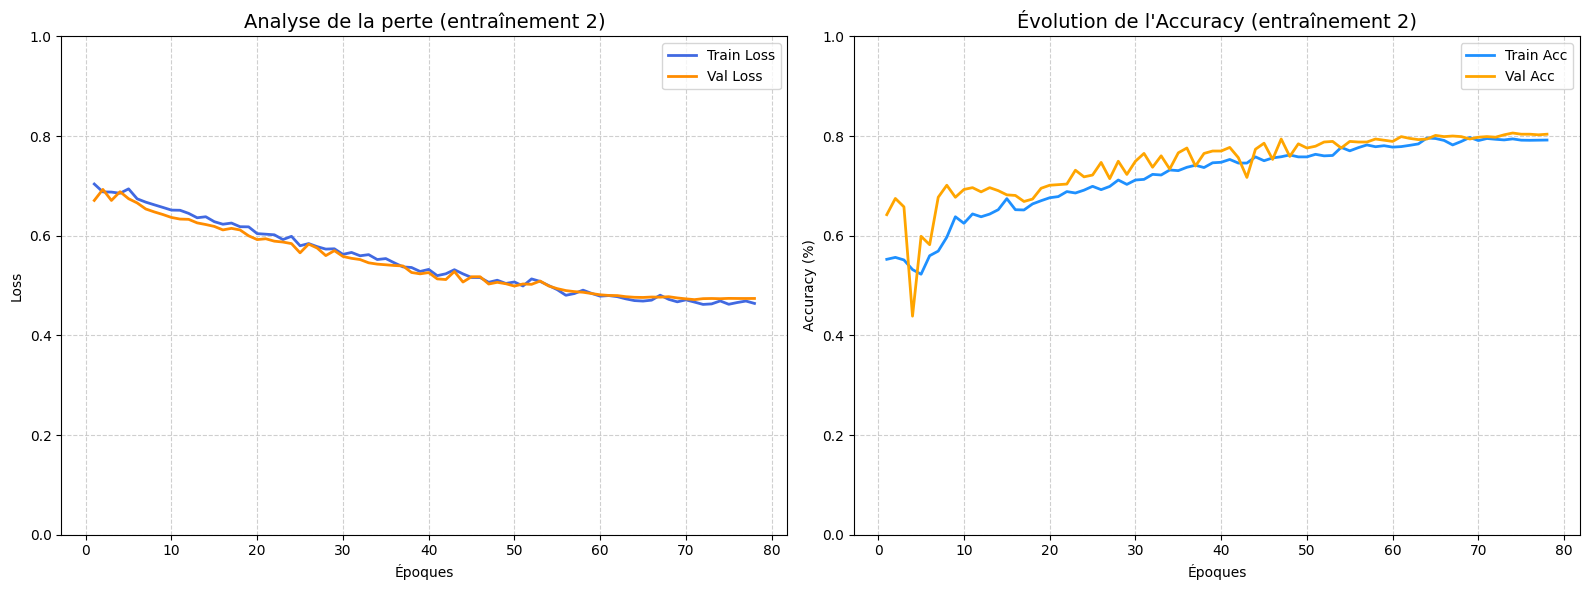

In [35]:
# graphique de l'évolution des loss et accuracy

import matplotlib.pyplot as plt

# Création d'une figure avec deux zones (1 ligne, 2 colonnes)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs = range(1, len(history['train_loss']) + 1)

# --- GRAPHIQUE 1 : LOSS ---
ax1.plot(epochs, history['train_loss'], label='Train Loss', color='royalblue', linewidth=2, markersize=4)
ax1.plot(epochs, history['val_loss'], label='Val Loss', color='darkorange', linewidth=2, markersize=4)

ax1.set_title("Analyse de la perte (entraînement 2)", fontsize=14)
ax1.set_xlabel("Époques")
ax1.set_ylabel("Loss")
ax1.set_ylim(0,1)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- GRAPHIQUE 2 : ACCURACY  ---
ax2.plot(epochs, history['train_accuracy'], label='Train Acc', color='dodgerblue', linewidth=2, markersize=4)
ax2.plot(epochs, history['val_accuracy'], label='Val Acc', color='orange', linewidth=2, markersize=4)

ax2.set_title("Évolution de l'Accuracy (entraînement 2)", fontsize=14)
ax2.set_xlabel("Époques")
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim(0,1)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## 5. Test et analyse

In [37]:
# Fonction de test

def test_model(model, ld, criterion):
    model.eval() # Mode évaluation (désactive le Dropout)
    test_loss_sum = 0
    accuracy_fn.reset()

    # Listes pour stocker les prédictions (utile pour la matrice de confusion plus tard)
    all_preds = []
    all_labels = []

    with torch.no_grad(): # Pas de calcul de gradient (gain de mémoire et vitesse)
        for images, labels in test_ld:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Calcul des prédictions
            _, preds = torch.max(outputs, 1)

            # Accumulation des stats
            test_loss_sum += loss.item() * images.size(0)
            accuracy_fn.update(preds, labels)

            # Stockage pour analyse détaillée
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = test_loss_sum / len(test_ld.dataset)
    test_acc = accuracy_fn.compute().item()

    print(f"--- RÉSULTATS TEST ---")
    print(f"Test Loss : {test_loss:.4f}")
    print(f"Test Accuracy : {test_acc * 100:.2f}%")

    return test_acc, all_preds, all_labels

# Exécution du test
test_acc, y_pred, y_true = test_model(model_mlp, test_ld, criterion)



--- RÉSULTATS TEST ---
Test Loss : 0.4992
Test Accuracy : 78.43%


**ANALYSE :**

On obtient une performance satisfaisante pour un MLP sur le jeu de test. On vérifie le recall à l'aide d'une matrice de confusion.

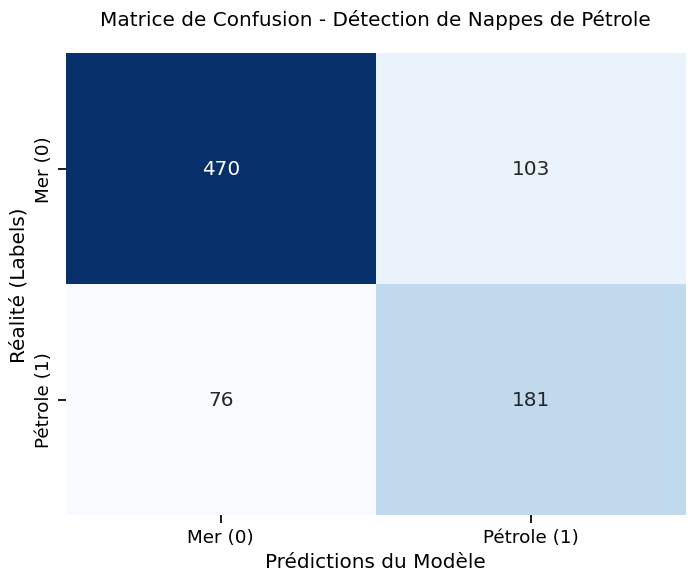


STATISTIQUES DÉTAILLÉES :
              precision    recall  f1-score   support

         Mer       0.86      0.82      0.84       573
     Pétrole       0.64      0.70      0.67       257

    accuracy                           0.78       830
   macro avg       0.75      0.76      0.75       830
weighted avg       0.79      0.78      0.79       830



In [38]:
# Calcul de la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Visualisation
plt.figure(figsize=(8, 6))
sns.set_context("notebook", font_scale=1.2)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Mer (0)', 'Pétrole (1)'],
            yticklabels=['Mer (0)', 'Pétrole (1)'])

plt.title('Matrice de Confusion - Détection de Nappes de Pétrole', pad=20)
plt.xlabel('Prédictions du Modèle')
plt.ylabel('Réalité (Labels)')
plt.show()

# Affichage du rapport détaillé (Précision, Rappel, F1-score)
print("\n" + "="*60)
print("STATISTIQUES DÉTAILLÉES :")
print("="*60)
print(classification_report(y_true, y_pred, target_names=['Mer', 'Pétrole']))

Pour une analyse détaillée, consulter le rapport.

**CONCLUSION :**

Le MLP ne permet d'obtenir un ratio de recall satisfaisant entre le deux classes.

On a soit un taux de fausses alertes trop élevé, soit un trop grand nombre de faux négatifs (marées noires non-détectées). On se tourne donc vers une architecture de CNN en espérant obtenir de meilleurs résultats.